In [1]:
# Get ERK
import os
import tifffile as tiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from skimage.segmentation import expand_labels
from skimage.measure import regionprops_table
from tqdm.notebook import tqdm

# --- Paths ---
IMG_DIR_PATH = '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged'
MASK_DIR_PATH = '/home/nbahou/myimaging/apoDet_refactored/data/paolo_data_d5_c12/tracked_masks_tiff' 
META_DIR_PATH = '/home/nbahou/myimaging/apoDet_refactored/data/paolo_data_d5_c12/windows_20x'



filenames = os.listdir(IMG_DIR_PATH)

file_paths = [IMG_DIR_PATH + "/" + name for name in filenames]
file_paths

['/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position04.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position03.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position02.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position05.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position08.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position06.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position01.tif',
 '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged/Position07.tif']

File: Position04.tif
Image Shape: (1480, 2, 1024, 1024)


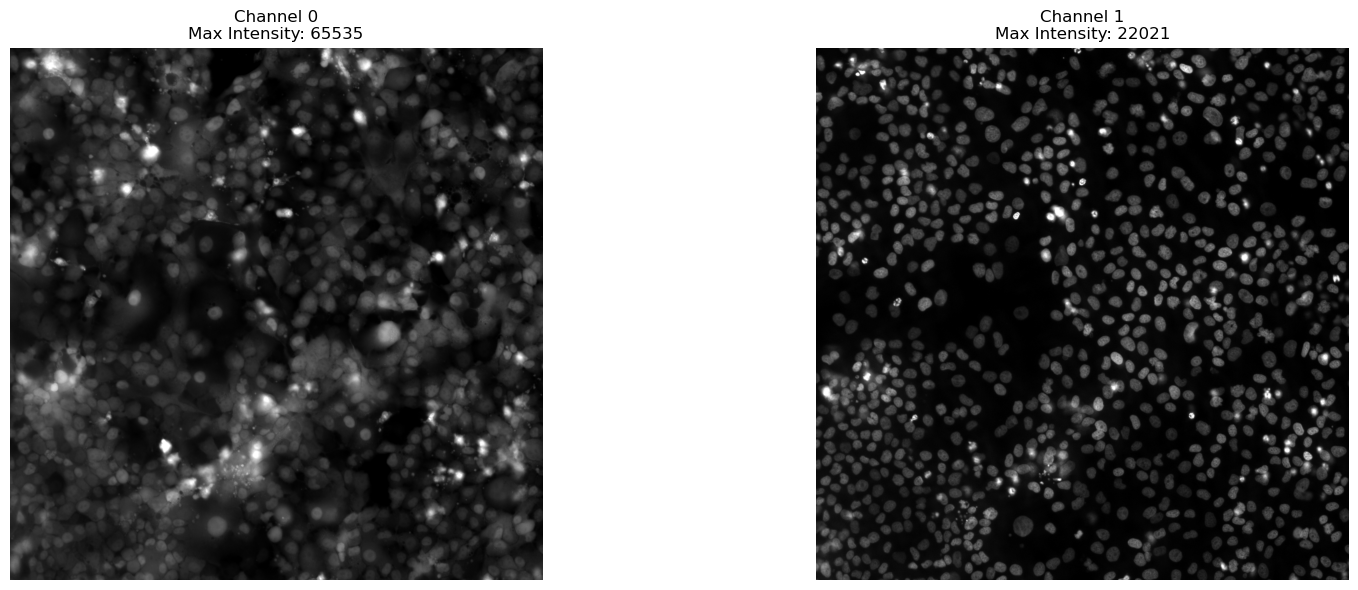

In [3]:
# Show examples of the available channels
# Pick the first file from your list
sample_path = file_paths[0]
img = tiff.imread(sample_path)

print(f"File: {os.path.basename(sample_path)}")
print(f"Image Shape: {img.shape}")

# Assuming shape is (Time, Channel, Y, X)
# Let's look at the first timepoint (t=0)
t_idx = 700
n_channels = img.shape[1] 

fig, axes = plt.subplots(1, n_channels, figsize=(18, 6))

for c in range(n_channels):
    # Slice: Time 0, Channel c, all Y, all X
    data = img[t_idx, c, :, :]
    
    # Use a robust contrast scaling (1st to 99th percentile) to see dim signal
    vmin, vmax = np.percentile(data, [1, 99.9])
    
    axes[c].imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    axes[c].set_title(f"Channel {c}\nMax Intensity: {np.max(data)}")
    axes[c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Extract ERK C/N for the first position of every sc-crop 

def map_filenames(meta_filename):
    """
    Maps 'metadata_Exp17_Site01.csv' to:
    - tif_name: 'Position01.tif'
    - npz_name: 'Exp17_Site01.npz'
    """
    match = re.search(r'Site(\d+)', meta_filename)
    if match:
        site_num = match.group(1)
        # Raw images use 'PositionXX', Masks use 'Exp17_SiteXX'
        tif_name = f"Position{site_num}.tif"
        npz_name = meta_filename.replace('metadata_', '').replace('.csv', '.npz')
        return tif_name, npz_name
    return None, None

# Updated to match your metadata naming pattern
meta_files = sorted([f for f in os.listdir(META_DIR_PATH) if f.startswith('metadata_Exp17') and f.endswith('.csv')])
all_results = []

for meta_file in tqdm(meta_files, desc="Processing Sites"):
    df_meta = pd.read_csv(os.path.join(META_DIR_PATH, meta_file))
    
    tif_name, npz_name = map_filenames(meta_file)
    tif_path = os.path.join(IMG_DIR_PATH, tif_name)
    mask_path = os.path.join(MASK_DIR_PATH, npz_name)
    
    if not os.path.exists(tif_path) or not os.path.exists(mask_path):
        print(f"Skipping {meta_file}: {tif_name} or {npz_name} missing.")
        continue

    # --- Loading ---
    # Assuming (T, C, Y, X) order for the TIFF
    img_stack = tiff.imread(tif_path) 
    
    with np.load(mask_path) as data:
        mask_key = data.files[0] 
        mask_stack = data[mask_key]
    
    frames_to_process = df_meta['t_start'].unique()
    fov_measurements = []

    for t_start in frames_to_process:
        # Generate the sequence of 12 frames (delta of 5)
        t_sequence = [t_start + (5 * i) for i in range(12)]
        
        # Store all frame measurements for this specific t_start cohort
        window_measurements = []
        
        for t_current in t_sequence:
            # Skip if the frame is beyond the image stack duration
            if t_current >= img_stack.shape[0]: 
                continue
                
            # Get ERK (assumed channel 0 based on original code) and Mask for the current frame
            # TODO: Change here if you want more than just ERK at the first position. Needs extra logic though.
            erk_t = img_stack[t_current, 0, :, :] 
            mask_t = mask_stack[t_current]

            # --- Donut Logic ---
            nucleus_mask = mask_t 
            inner_buffer = expand_labels(mask_t, 2)
            outer_edge = expand_labels(mask_t, 6)
            cyto_ring_mask = np.where(inner_buffer > 0, 0, outer_edge)

            # --- Extraction ---
            props_nuc = regionprops_table(nucleus_mask, intensity_image=erk_t, properties=('label', 'mean_intensity'))
            df_nuc = pd.DataFrame(props_nuc).rename(columns={'label': 'track_id', 'mean_intensity': 'nuc_ERK'})
            
            props_cyto = regionprops_table(cyto_ring_mask, intensity_image=erk_t, properties=('label', 'mean_intensity'))
            df_cyto = pd.DataFrame(props_cyto).rename(columns={'label': 'track_id', 'mean_intensity': 'cyto_ERK'})
            
            # Combine frame data and calculate C/N ratio for THIS specific frame
            df_frame = pd.merge(df_nuc, df_cyto, on='track_id', how='inner')
            df_frame['t_current'] = t_current 
            df_frame['frame_erk_CN'] = df_frame['cyto_ERK'] / (df_frame['nuc_ERK'] + 1e-6)
            
            window_measurements.append(df_frame)

        if not window_measurements:
            continue
            
        # Combine all processed frames for this t_start into one DataFrame
        df_window = pd.concat(window_measurements, ignore_index=True)
        
        # 1. Extract the initial C/N ratio (specifically at t_start)
        df_t0 = df_window[df_window['t_current'] == t_start][['track_id', 'frame_erk_CN']].copy()
        df_t0.rename(columns={'frame_erk_CN': 'erk_CN'}, inplace=True)
        
        # 2. Calculate the mean C/N ratio across all frames in the 12-frame window per cell
        df_mean = df_window.groupby('track_id')['frame_erk_CN'].mean().reset_index()
        df_mean.rename(columns={'frame_erk_CN': 'mean_erk_CN'}, inplace=True)
        
        # Merge the t_start ratio and the mean ratio side-by-side
        df_cohort = pd.merge(df_t0, df_mean, on='track_id', how='outer')
        df_cohort['t_start'] = t_start
        
        fov_measurements.append(df_cohort)

    # --- Merge with Meta ---
    if fov_measurements:
        site_measurements = pd.concat(fov_measurements, ignore_index=True)
        
        # Merge results into the meta dataframe for this site
        # Now joining 'erk_CN' AND 'mean_erk_CN'
        df_meta_updated = pd.merge(df_meta, site_measurements[['track_id', 't_start', 'erk_CN', 'mean_erk_CN']], 
                                   on=['track_id', 't_start'], how='left')
        all_results.append(df_meta_updated)

# Concatenate all sites into one large dataframe
final_df = pd.concat(all_results, ignore_index=True)
print(f"Finished! Processed {len(all_results)} sites. Final shape: {final_df.shape}")

Processing Sites:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
final_df.to_csv("pao_d5_c6_metadata_w_erk_mean.csv")

## Sanity Checks

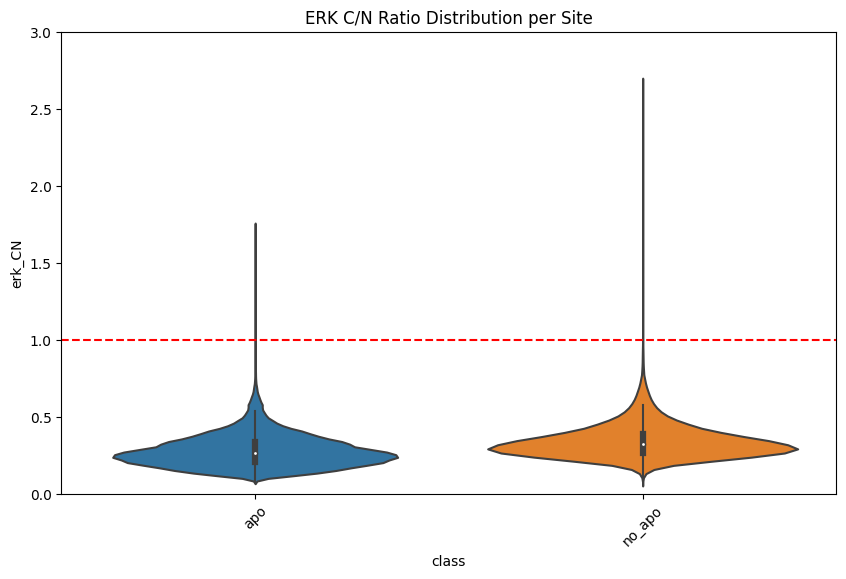

Total rows: 789859
Rows missing ERK data: 36 (0.00%)


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Quick distribution check
plt.figure(figsize=(10, 6))
sns.violinplot(data=final_df, x='class', y='erk_CN')
plt.xticks(rotation=45)
plt.title("ERK C/N Ratio Distribution per Site")
plt.ylim(0, 3) # Ratios usually sit in this range
plt.axhline(1.0, color='red', linestyle='--') # 1.0 is the "neutral" line
plt.show()

# 2. Check for missing data
missing_count = final_df['erk_CN'].isna().sum()
print(f"Total rows: {len(final_df)}")
print(f"Rows missing ERK data: {missing_count} ({missing_count/len(final_df)*100:.2f}%)")

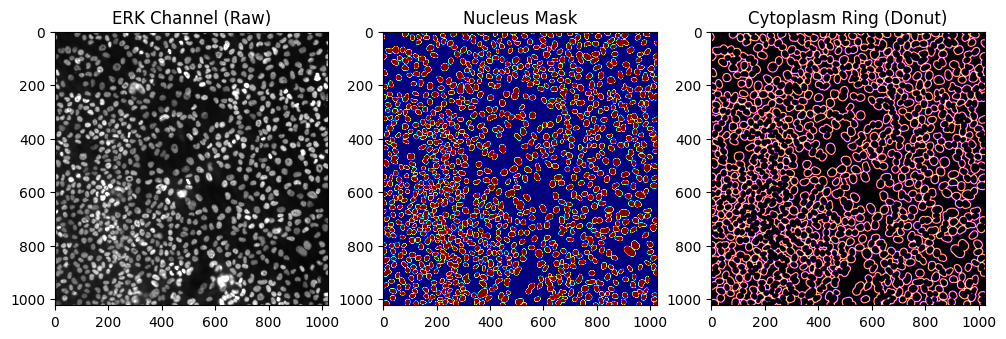

In [18]:
# Use the last processed t and mask_t from the loop above
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.title("ERK Channel (Raw)")
plt.imshow(erk_t, cmap='gray', vmax=np.percentile(erk_t, 99))

plt.subplot(132)
plt.title("Nucleus Mask")
plt.imshow(nucleus_mask > 0, cmap='jet')

plt.subplot(133)
plt.title("Cytoplasm Ring (Donut)")
plt.imshow(cyto_ring_mask > 0, cmap='magma')

plt.show()

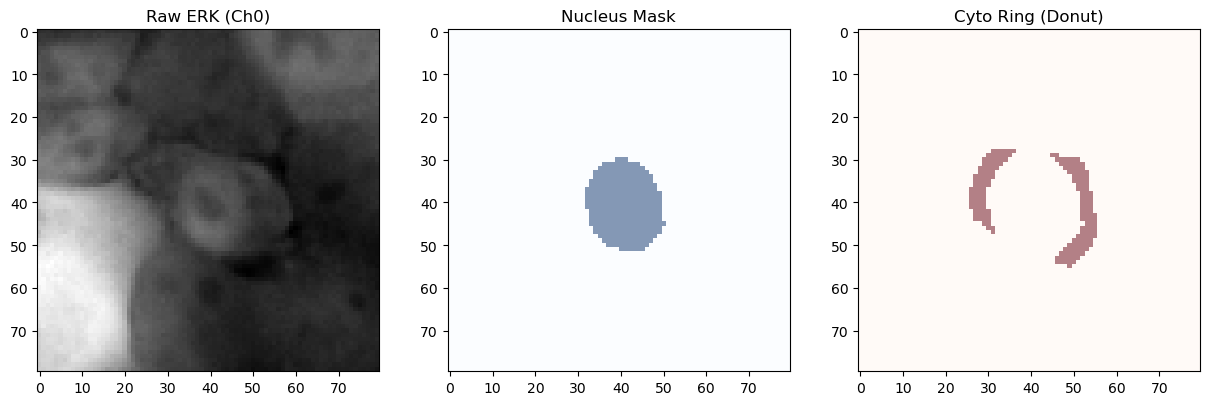

In [8]:
import matplotlib.pyplot as plt

# Let's look at one cell from the last frame processed
sample_id = df_frame['track_id'].iloc[3] # Take the first cell found
y, x = np.where(mask_t == sample_id)
yc, xc = int(np.mean(y)), int(np.mean(x))
w = 40 # window size for crop

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
crop_erk = erk_t[yc-w:yc+w, xc-w:xc+w]
crop_nuc = mask_t[yc-w:yc+w, xc-w:xc+w] == sample_id
crop_ring = cyto_ring_mask[yc-w:yc+w, xc-w:xc+w] == sample_id

ax[0].imshow(crop_erk, cmap='gray')
ax[0].set_title("Raw ERK (Ch0)")
ax[1].imshow(crop_nuc, cmap='Blues', alpha=0.5)
ax[1].set_title("Nucleus Mask")
ax[2].imshow(crop_ring, cmap='Reds', alpha=0.5)
ax[2].set_title("Cyto Ring (Donut)")
plt.show()

In [15]:
final_df

,file_path,filename,track_id,t_start,y_center,x_center,window_size,class,erk_CN
0,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,230,200.0,64.0,32,apo,0.272887
1,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,232,200.0,62.0,32,apo,0.267142
2,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,233,200.0,62.0,32,apo,0.286104
3,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,235,198.0,62.0,32,apo,0.252120
4,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,237,200.0,62.0,32,apo,0.244851
...,...,...,...,...,...,...,...,...,...
789854,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1421,798.0,382.0,32,no_apo,0.383360
789855,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1422,798.0,382.0,32,no_apo,0.383964
789856,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1423,798.0,382.0,32,no_apo,0.383326
789857,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1424,798.0,382.0,32,no_apo,0.382520


In [11]:
import pandas as pd
from tqdm.notebook import tqdm

# Load the CSV
ERK_CSV_PATH = '/home/nbahou/myimaging/apoDet_refactored/pao_d5_c6_metadata_w_erk.csv'
df_erk = pd.read_csv(ERK_CSV_PATH)

# Ensure data types match for merging (important for track_id)
df_erk['track_id'] = df_erk['track_id'].astype(int)
df_erk['t_start'] = df_erk['t_start'].astype(int)

print(f"Loaded ERK data: {df_erk.shape[0]} rows.")

ERROR! Session/line number was not unique in database. History logging moved to new session 1234
Loaded ERK data: 789859 rows.


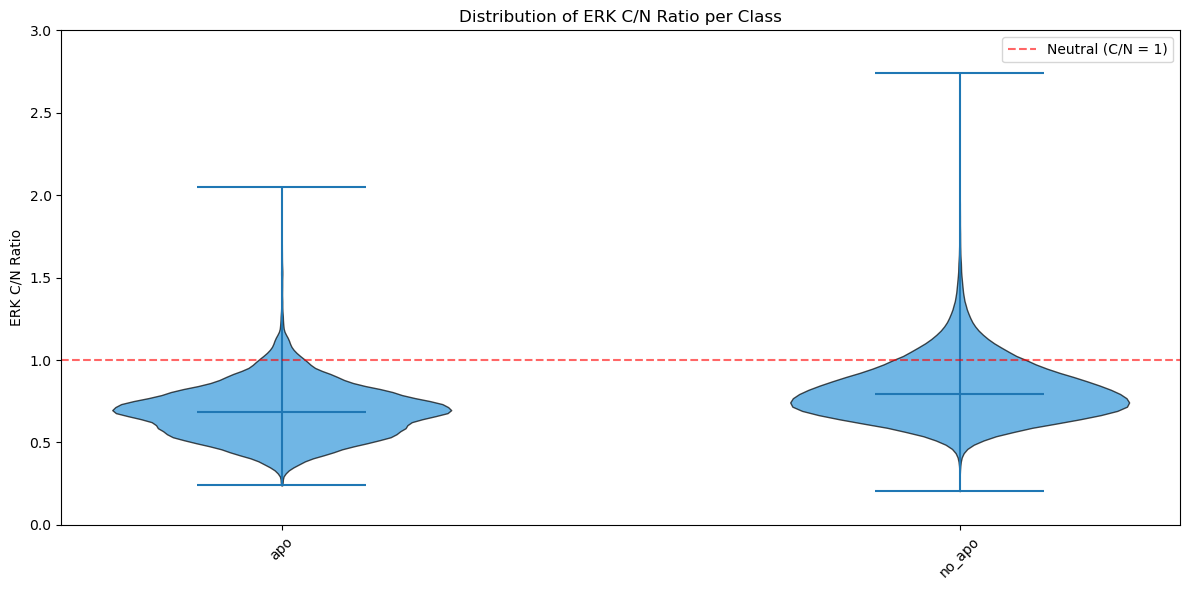

NameError: name 'final_df' is not defined

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean the data for plotting (remove NaNs in the columns we need)
df_plot = df_erk.dropna(subset=['erk_CN', 'class'])

# 2. Get the unique classes and sort them so the plot is organized
classes = sorted(df_plot['class'].unique())

# 3. Create a list where each element is an array of ERK values for that class
data_to_plot = [df_plot[df_plot['class'] == c]['erk_CN'].values for c in classes]

# 4. Initialize the figure
plt.figure(figsize=(12, 6))

# 5. Create the violin plot
# positions 1, 2, 3... correspond to the order in our 'classes' list
vplot = plt.violinplot(data_to_plot, showmedians=True)

# Optional: Make the violins look a bit nicer
for body in vplot['bodies']:
    body.set_facecolor('#3498db') # A nice blue
    body.set_alpha(0.7)
    body.set_edgecolor('black')

# 6. Formatting
plt.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Neutral (C/N = 1)')
plt.xticks(range(1, len(classes) + 1), classes, rotation=45)
plt.ylabel("ERK C/N Ratio")
plt.title("Distribution of ERK C/N Ratio per Class")
plt.ylim(0, 3) # Standard range for KTR sensors
plt.legend()

plt.tight_layout()
plt.show()

# 7. Quick Stats Check
print(f"Unique classes found: {classes}")

## Legacy
The code below was used to generate the ERK_UMAP, the new version above should also be able to extract mean C/N but is not tested

In [13]:
# old erk extraction
import os
import re
import tifffile as tiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.segmentation import expand_labels
from skimage.measure import regionprops_table
from tqdm.notebook import tqdm

# --- Paths ---
IMG_DIR_PATH = '/mnt/imaging.data/pgagliardi/MCF10A_Optogenetics/20190503_test_parallelStim_differentFreq1_30min/Merged'
MASK_DIR_PATH = '/home/nbahou/myimaging/apoDet_refactored/data/paolo_data_d5_c12/tracked_masks_tiff' 
META_DIR_PATH = '/home/nbahou/myimaging/apoDet_refactored/data/paolo_data_d5_c12/windows_20x'

def map_filenames(meta_filename):
    """
    Maps 'metadata_Exp17_Site01.csv' to:
    - tif_name: 'Position01.tif'
    - npz_name: 'Exp17_Site01.npz'
    """
    match = re.search(r'Site(\d+)', meta_filename)
    if match:
        site_num = match.group(1)
        # Raw images use 'PositionXX', Masks use 'Exp17_SiteXX'
        tif_name = f"Position{site_num}.tif"
        npz_name = meta_filename.replace('metadata_', '').replace('.csv', '.npz')
        return tif_name, npz_name
    return None, None

# Updated to match your metadata naming pattern
meta_files = sorted([f for f in os.listdir(META_DIR_PATH) if f.startswith('metadata_Exp17') and f.endswith('.csv')])
all_results = []

for meta_file in tqdm(meta_files, desc="Processing Sites"):
    df_meta = pd.read_csv(os.path.join(META_DIR_PATH, meta_file))
    
    tif_name, npz_name = map_filenames(meta_file)
    tif_path = os.path.join(IMG_DIR_PATH, tif_name)
    mask_path = os.path.join(MASK_DIR_PATH, npz_name)
    
    if not os.path.exists(tif_path) or not os.path.exists(mask_path):
        print(f"Skipping {meta_file}: {tif_name} or {npz_name} missing.")
        continue

    # --- Loading ---
    # Assuming (T, C, Y, X) order for the TIFF
    img_stack = tiff.imread(tif_path) 
    
    with np.load(mask_path) as data:
        mask_key = data.files[0] 
        mask_stack = data[mask_key]
    
    frames_to_process = df_meta['t_start'].unique()
    fov_measurements = []

    for t in frames_to_process:
        if t >= img_stack.shape[0]: continue
            
        # Get ERK (2nd channel) and Mask for frame t
        erk_t = img_stack[t, 0, :, :] 
        mask_t = mask_stack[t]

        # --- Donut Logic ---
        nucleus_mask = mask_t 
        inner_buffer = expand_labels(mask_t, 2)
        outer_edge = expand_labels(mask_t, 6)
        # Ring: everything in outer edge except the inner buffer
        cyto_ring_mask = np.where(inner_buffer > 0, 0, outer_edge)

        # --- Extraction using regionprops_table ---
        props_nuc = regionprops_table(nucleus_mask, intensity_image=erk_t, properties=('label', 'mean_intensity'))
        df_nuc = pd.DataFrame(props_nuc).rename(columns={'label': 'track_id', 'mean_intensity': 'nuc_ERK'})
        
        props_cyto = regionprops_table(cyto_ring_mask, intensity_image=erk_t, properties=('label', 'mean_intensity'))
        df_cyto = pd.DataFrame(props_cyto).rename(columns={'label': 'track_id', 'mean_intensity': 'cyto_ERK'})
        
        # Combine frame data
        df_frame = pd.merge(df_nuc, df_cyto, on='track_id', how='inner')
        df_frame['t_start'] = t
        fov_measurements.append(df_frame)

    # --- Merge with Meta ---
    if fov_measurements:
        site_measurements = pd.concat(fov_measurements, ignore_index=True)
        # Calculate C/N ratio
        site_measurements['erk_CN'] = site_measurements['cyto_ERK'] / (site_measurements['nuc_ERK'] + 1e-6)
        
        # Merge results into the meta dataframe for this site
        df_meta_updated = pd.merge(df_meta, site_measurements[['track_id', 't_start', 'erk_CN']], 
                                   on=['track_id', 't_start'], how='left')
        all_results.append(df_meta_updated)

# Concatenate all sites into one large dataframe
final_df = pd.concat(all_results, ignore_index=True)
print(f"Finished! Processed {len(all_results)} sites. Final shape: {final_df.shape}")

'/home/nbahou/myimaging/apoDet_refactored/data/paolo_data_d5_c12/tracked_masks_tiff/Position08.tif'